# ANÁLISIS DE TORNEO DE FÚTBOL - Validación de Hipótesis

## Importaciones

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from soccer_sim import Team, Tournament

np.random.seed(42)

N_SIMULATIONS = 1000
BASE_STRENGTH = 75
FATIGUE_EFFECT = 0.04
INJURY_PROB = 0.03
GROUP_SIZE = 4

## Ejecución de Simulaciones

In [ ]:
def run_simulations(n_simulations):
    base_teams = [Team(f"T{i}", np.random.randint(-40, 95)) for i in range(16)]
    all_results = []
    
    for _ in range(n_simulations):
        teams = [Team(t.name, t.base_strength) for t in base_teams]
        tournament = Tournament(
            teams,
            fatigue_effect=FATIGUE_EFFECT,   # fatiga por partido
            injury_prob=INJURY_PROB,      # probabilidad de lesión
            group_size=GROUP_SIZE
        )
        tournament.run()
        all_results.append(tournament.sim_result)
    
    return all_results

def process_results(results):
    match_data = []
    penalty_data = []
    team_data = []
    
    for res in results:
        for match in res.match_data:
            match_data.append({
                "Style_A": match.style_a,
                "Style_B": match.style_b,
                "Goals_A": match.goals_a,
                "Goals_B": match.goals_b,
                "Stage": match.stage
            })
            
        for penalty in res.penalty_data:
            penalty_data.append({
                "Skill_A": penalty.skill_a,
                "Skill_B": penalty.skill_b,
                "Winner_Skill": penalty.skill_a if penalty.winner == penalty.team_a else penalty.skill_b
            })
            
        for team in res.team_records:
            team_data.append({
                "Team": team.name,
                "Attack": team.attack_strength,
                "Defense": team.defense_strength,
                "Style": team.play_style,
                "Consistency": team.consistency,
                "Penalty_Skill": team.penalty_skill,
                "Stage": team.stage_reached,
                "Fatigue": team.fatigue * 100,
                "Injuries": team.injuries,
                "Points": team.points
            })
    
    return pd.DataFrame(match_data), pd.DataFrame(penalty_data), pd.DataFrame(team_data)


## Ejecutar simulaciones

In [21]:
print("⚽ Ejecutando simulaciones...")
results = run_simulations(N_SIMULATIONS)
print("✅ Simulaciones completadas!")

# Procesar datos
match_df, penalty_df, team_df = process_results(results)

⚽ Ejecutando simulaciones...
✅ Simulaciones completadas!


## Análisis de Datos

#### Extraer datos numéricos para análisis
Seleccionamos variables específicas que son relevantes para nuestras hipótesis

In [22]:
team_numeric = team_df.select_dtypes(include=['number']).drop(columns=['Team'], errors='ignore')
match_numeric = match_df.select_dtypes(include=['number'])

#### Análisis de normalidad para variables clave
Creamos QQ-Plots para variables seleccionadas que esperamos tengan distribución normal

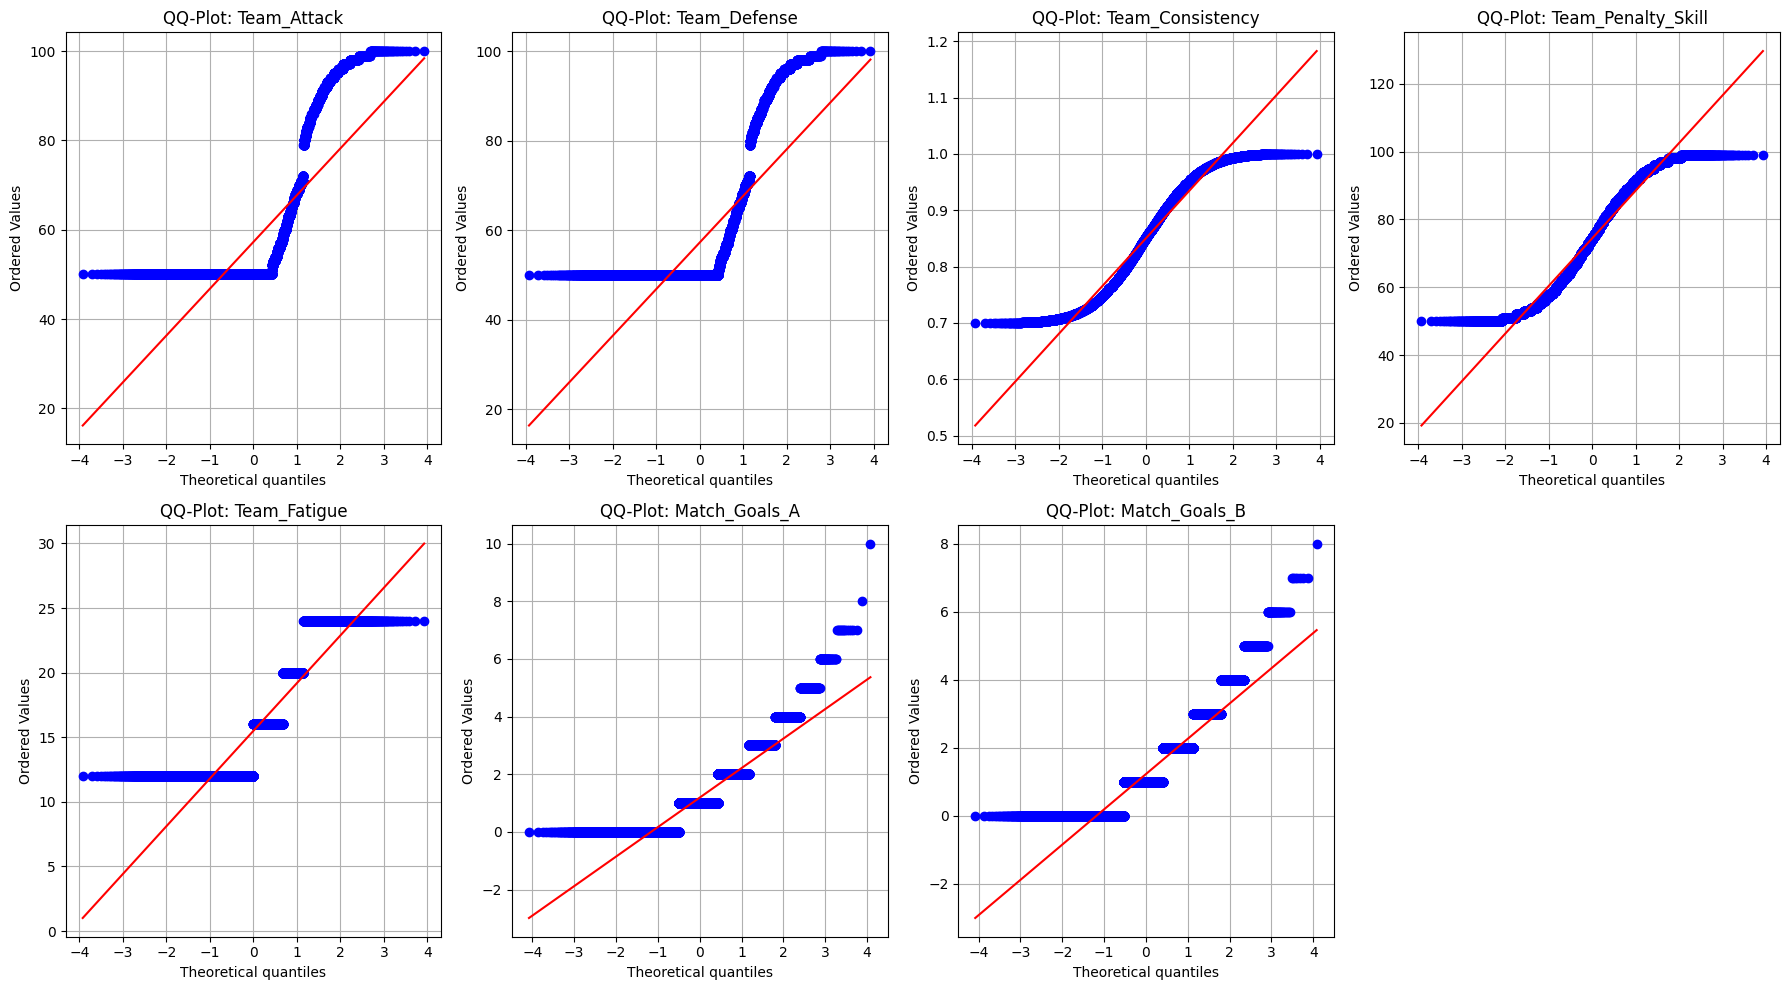

In [23]:

key_variables = {
    'Team_Attack': team_df['Attack'],
    'Team_Defense': team_df['Defense'],
    'Team_Consistency': team_df['Consistency'],
    'Team_Penalty_Skill': team_df['Penalty_Skill'],
    'Team_Fatigue': team_df['Fatigue'],
    'Match_Goals_A': match_df['Goals_A'],
    'Match_Goals_B': match_df['Goals_B']
}

# Creamos QQ-Plots para variables seleccionadas
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, (name, data) in enumerate(key_variables.items()):
    if i < len(axes):
        stats.probplot(data, dist="norm", plot=axes[i])
        axes[i].set_title(f'QQ-Plot: {name}')
        axes[i].grid(True)

# Ocultamos el último eje si hay un número impar de variables
if len(key_variables) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación de los QQ-Plots**
Los QQ-Plots comparan la distribución de tus datos con una distribución normal teórica (representada por la línea roja diagonal). Cuando los puntos azules siguen la línea roja, indica que la variable sigue una distribución normal.

**Variables de Equipos:**
1. Team_Attack y Team_Defense :
   
   - Ambas muestran un patrón escalonado con tres niveles distintos (alrededor de 50, 70 y 100)
   - No siguen una distribución normal.
   - Esto refleja cómo se generan los equipos en la simulación, con fuerzas base aleatorias que luego se ajustan
2. Team_Consistency :
   
   - Muestra una distribución más cercana a la normal en el rango central (0.7-0.9)
   - Tiene un límite superior en 1.0 (valor máximo de consistencia)
   - Se desvía ligeramente de la normalidad en los extremos
3. Team_Penalty_Skill :
   
   - Similar a Attack y Defense, muestra una distribución escalonada
   - Concentración de valores entre 50-100, como se define en la inicialización
4. Team_Fatigue :
   
   - Distribución discreta con valores específicos (12%, 16%, 20%, 24%)
   - Refleja la acumulación de fatiga por partido (4% por partido jugado)

**Variables de Partidos:**
5. Match_Goals_A y Match_Goals_B :
   - Distribución discreta (0, 1, 2, 3...)
   - Desviación significativa de la normalidad
   - Patrón consistente con una distribución de Poisson (como se modeló en la simulación)
   - Concentración en valores bajos con cola hacia la derecha

**Implicaciones para la Simulación**
Con esta información tenemos:

1. Validación del Modelo :
   
   - Confirma que la generación de goles sigue una distribución de Poisson como se esperaba
   - Verifica que los atributos de los equipos se generan según los parámetros establecidos
2. Selección de Pruebas Estadísticas :
   
   - La mayoría de las variables no siguen una distribución normal
   - Esto sugiere que deberíamos usar pruebas no paramétricas para análisis posteriores

3. Interpretación de Resultados :
   
   - Al analizar el rendimiento de los equipos, se debe considerar que las variables no son normales
   - Las comparaciones directas entre equipos deben tener en cuenta estas distribuciones
4. Hipótesis sobre Factores de Éxito :
   
   - La no-normalidad de las variables sugiere que la relación entre atributos y éxito podría ser no lineal
   - Esto justifica el uso de análisis más complejos para entender qué factores determinan el éxito en el torneo


#### Análisis de correlación entre variables clave

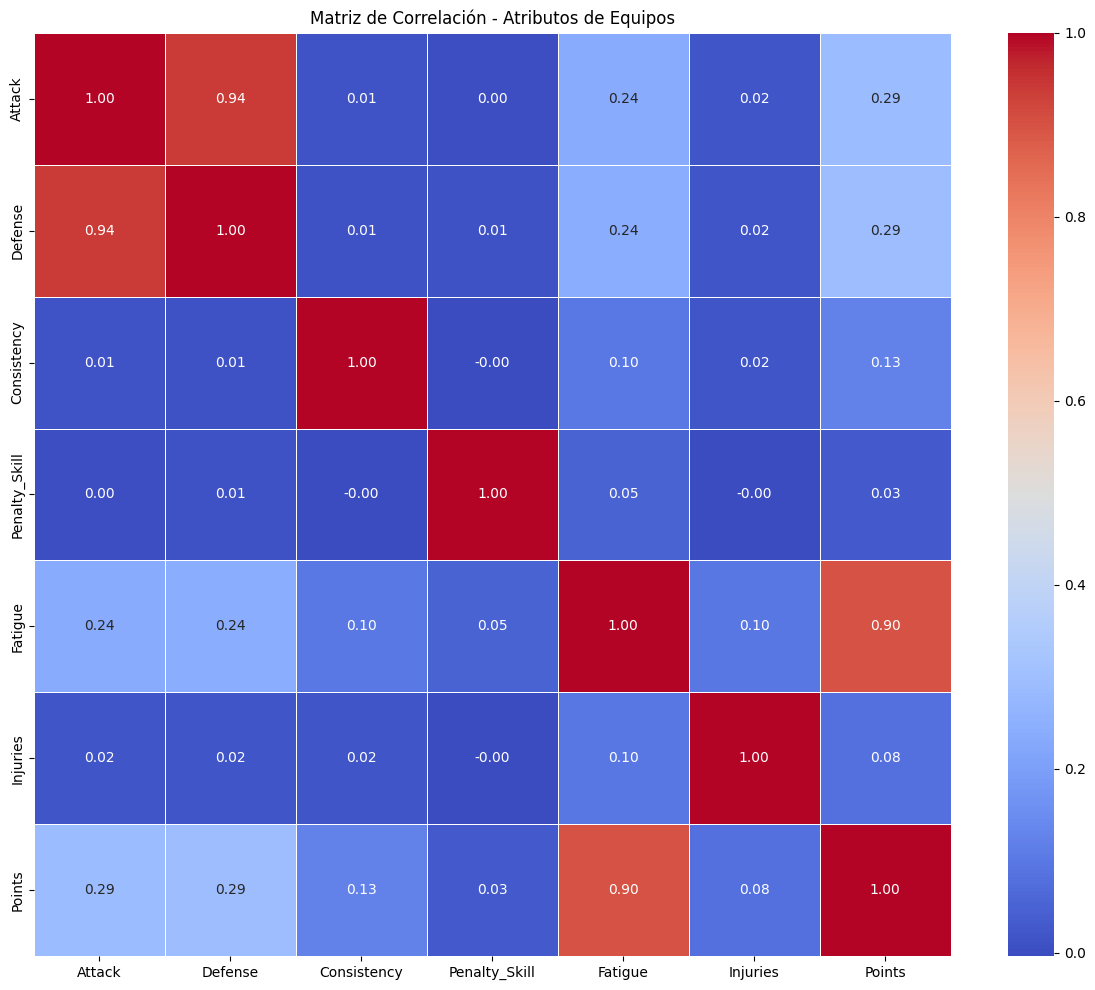

In [24]:
plt.figure(figsize=(12, 10))
correlation_matrix = team_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Atributos de Equipos')
plt.tight_layout()
plt.show()

**Correlaciones Principales**
1. Attack y Defense (0.94) :
   - Indica que los equipos fuertes tienden a ser buenos en ambos aspectos
2. Fatigue y Points (0.90) :
   - Sugiere que los equipos que avanzan más en el torneo acumulan más fatiga
   - Relación causal: más partidos jugados → más puntos y más fatiga
3. Independencia de Penalty_Skill (cercana a 0 con casi todas las variables) :
   - Confirma que la habilidad de penales se genera independientemente
4. Consistency (baja correlación con otras las variables) :
   - Confirma que se genera independientemente como se esperaba
5. Attack/Defense y Points (0.29) :
   - Sugiere que equipos más fuertes tienden a obtener más puntos, pero no es determinante

**Implicaciones para la Simulación**
Esta matriz de correlación nos ayuda en varios aspectos:
1. Validación del Modelo :
   - Confirma que las variables se generan según lo diseñado
   - La independencia de penalty_skill y consistency es consistente con el código
2. Interpretación de Resultados :
   - La correlación moderada entre fuerza y puntos indica que hay otros factores influyentes (como estilo de juego)

#### Análisis de distribución de goles

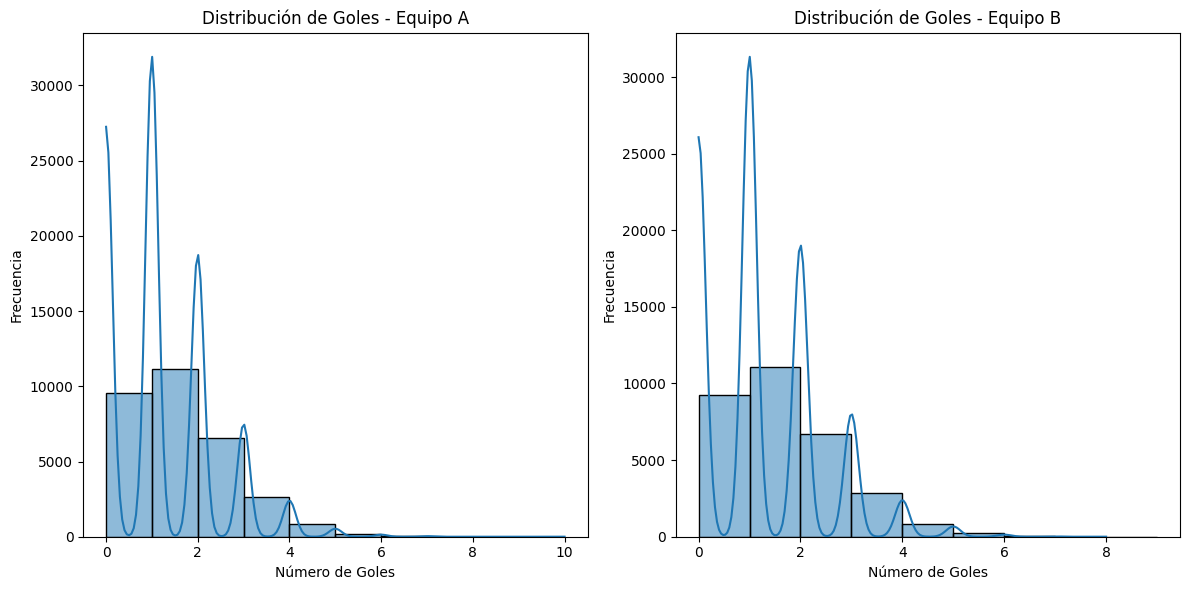

In [25]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(match_df['Goals_A'], kde=True, bins=range(0, 10))
plt.title('Distribución de Goles - Equipo A')
plt.xlabel('Número de Goles')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(match_df['Goals_B'], kde=True, bins=range(0, 10))
plt.title('Distribución de Goles - Equipo B')
plt.xlabel('Número de Goles')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Análisis de la Distribución de Goles**

Los gráficos muestran la distribución de goles marcados por los equipos A y B a lo largo de todas las simulaciones del torneo. Observamos características muy similares en ambas distribuciones:

**Características principales**

1. **Forma de la distribución**: Tiene distribución asimétrica positiva (cola hacia la derecha), además de una mayor concentración en valores bajos (0, 1, 2 goles). Asímismo su frecuencia que disminuye rápidamente para valores más altos

2. **Valores más frecuentes**: Tener 1 gol es el resultado más común,0 y 2 goles también son muy frecuentes, por tanto raramente se anotan más de 4 goles
.
3. **Patrón de Poisson**: La forma de la distribución es consistente con una distribución de Poisson,esto valida el modelo implementado en `simulate_match()` donde se usa `np.random.poisson(lambda_a)` y `np.random.poisson(lambda_b)`.


Por tanto confirmamos que la generación de goles sigue el patrón esperado de Poisson y demuestra que el cálculo de lambda (λ) basado en la relación ataque/defensa produce resultados realistas. Con esto la distribución se asemeja a las estadísticas reales de fútbol, donde los partidos con 0-3 goles son más comunes.

Esta distribución de goles es fundamental para el realismo de la simulación,el factor multiplicador 2.5 en el cálculo de lambda parece estar bien ajustado ya que reproduce adecuadamente la naturaleza de bajo puntaje del fútbol y la variabilidad inherente en los resultados de los partidos, donde incluso equipos más débiles pueden ocasionalmente ganar debido a la naturaleza estocástica de la anotación de goles.

#### Análisis de relación entre atributos y rendimiento

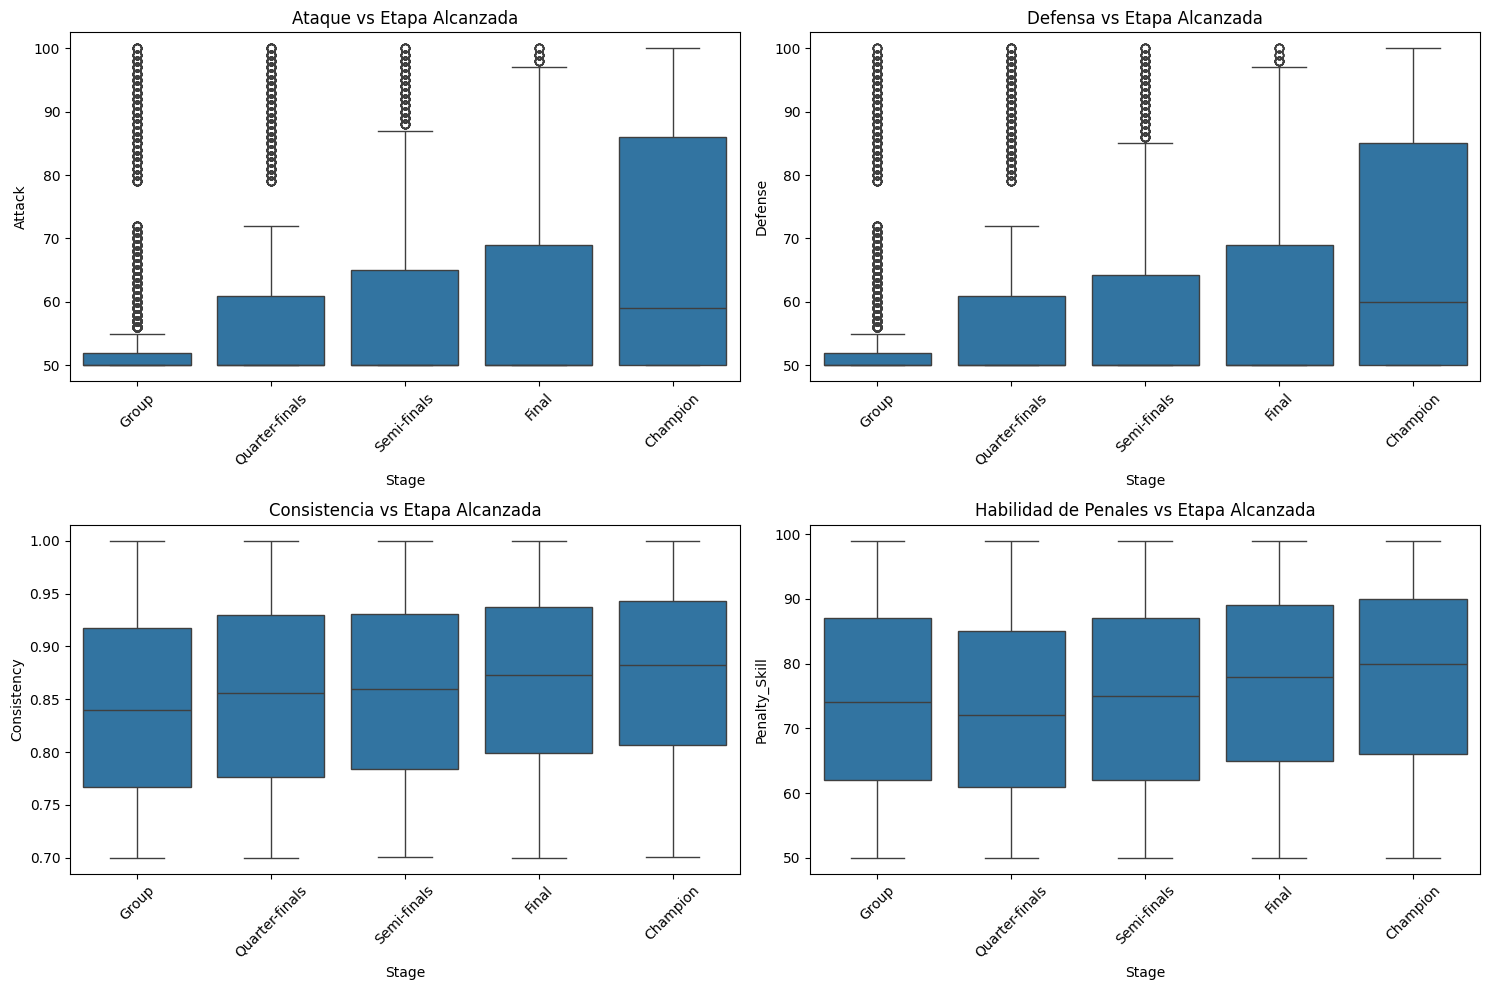

In [26]:

plt.figure(figsize=(15, 10))

# Convertir Stage a valor numérico para análisis
stage_order = {'Group': 0, 'Quarter-finals': 1, 'Semi-finals': 2, 'Final': 3, 'Champion': 4}
team_df['Stage_Value'] = team_df['Stage'].map(stage_order)

# Subplot 1: Relación entre Attack y Stage alcanzada
plt.subplot(2, 2, 1)
sns.boxplot(x='Stage', y='Attack', data=team_df, order=['Group', 'Quarter-finals', 'Semi-finals', 'Final', 'Champion'])
plt.title('Ataque vs Etapa Alcanzada')
plt.xticks(rotation=45)

# Subplot 2: Relación entre Defense y Stage alcanzada
plt.subplot(2, 2, 2)
sns.boxplot(x='Stage', y='Defense', data=team_df, order=['Group', 'Quarter-finals', 'Semi-finals', 'Final', 'Champion'])
plt.title('Defensa vs Etapa Alcanzada')
plt.xticks(rotation=45)

# Subplot 3: Relación entre Consistency y Stage alcanzada
plt.subplot(2, 2, 3)
sns.boxplot(x='Stage', y='Consistency', data=team_df, order=['Group', 'Quarter-finals', 'Semi-finals', 'Final', 'Champion'])
plt.title('Consistencia vs Etapa Alcanzada')
plt.xticks(rotation=45)

# Subplot 4: Relación entre Penalty_Skill y Stage alcanzada
plt.subplot(2, 2, 4)
sns.boxplot(x='Stage', y='Penalty_Skill', data=team_df, order=['Group', 'Quarter-finals', 'Semi-finals', 'Final', 'Champion'])
plt.title('Habilidad de Penales vs Etapa Alcanzada')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Análisis de Atributos de Equipos vs Etapa Alcanzada**

Los equipos con mayor ataque y defensa tienden a avanzar más en el torneo, con valores que aumentan progresivamente en cada etapa (mediana de 60 en grupos vs 85 para campeones). La consistencia muestra una tendencia ascendente leve (mediana de 0.85 vs 0.94 para campeones). La habilidad de penales cobra mayor importancia en etapas finales, reflejando su rol en partidos de eliminación directa. Se observa mayor dispersión de valores en etapas iniciales que en las finales para ataque/defensa, mientras que la consistencia mantiene dispersión similar en todas las etapas.

**Utilidad para la simulación**

Esta información valida nuestro modelo al confirmar que los atributos influyen en el rendimiento según lo esperado, favoreciendo a equipos fuertes pero permitiendo sorpresas. Demuestra un buen equilibrio donde ataque y defensa tienen impacto dominante, mientras consistencia y habilidad de penales juegan roles secundarios pero significativos. Permite calibrar la importancia relativa de cada atributo, confirmando que la fórmula para calcular goles está bien balanceada y que la habilidad de penales impacta adecuadamente en etapas avanzadas. Refleja el realismo del fútbol donde equipos más fuertes tienden a avanzar más, manteniendo suficiente variabilidad para permitir sorpresas ocasionales. Los gráficos confirman que el modelo captura adecuadamente la influencia de los atributos en el rendimiento del torneo.


#### Análisis de estilos de juego y su efectividad

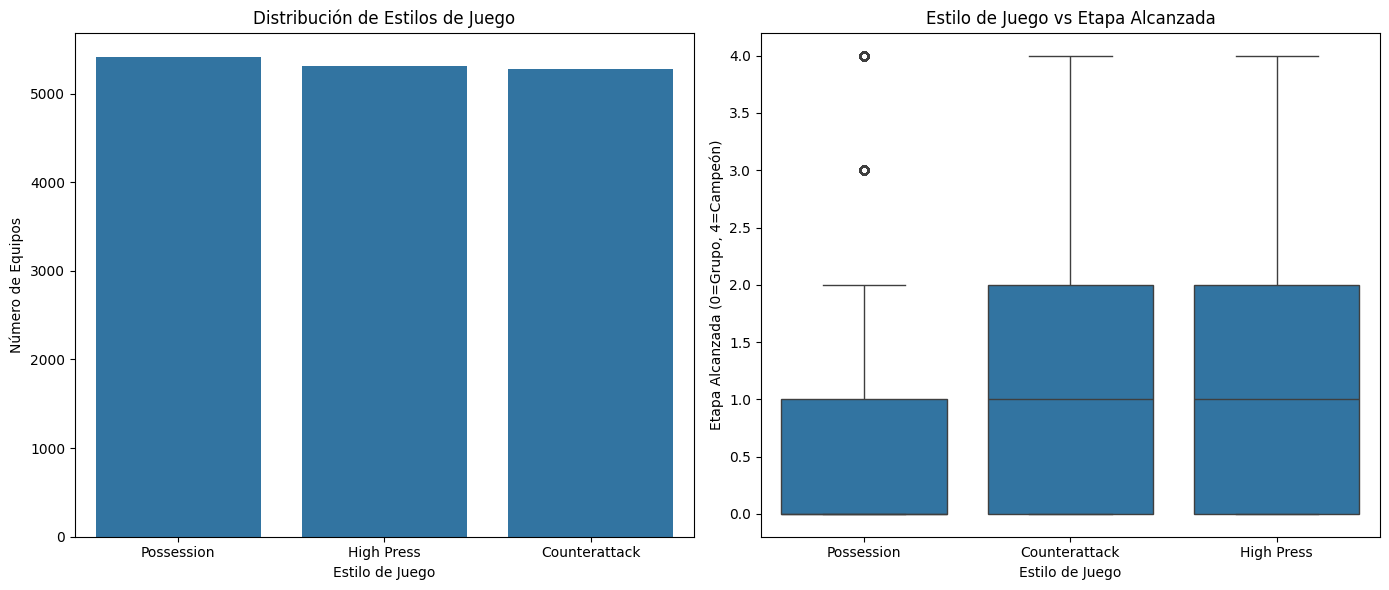

In [27]:

plt.figure(figsize=(14, 6))

# Subplot 1: Distribución de estilos de juego
plt.subplot(1, 2, 1)
style_counts = team_df['Style'].value_counts()
sns.barplot(x=style_counts.index, y=style_counts.values)
plt.title('Distribución de Estilos de Juego')
plt.ylabel('Número de Equipos')
plt.xlabel('Estilo de Juego')

# Subplot 2: Relación entre estilo de juego y etapa alcanzada
plt.subplot(1, 2, 2)
sns.boxplot(x='Style', y='Stage_Value', data=team_df)
plt.title('Estilo de Juego vs Etapa Alcanzada')
plt.ylabel('Etapa Alcanzada (0=Grupo, 4=Campeón)')
plt.xlabel('Estilo de Juego')

plt.tight_layout()
plt.show()

**Análisis de Estilos de Juego en la Simulación de Fútbol:**

**Distribución de Estilos de Juego**
- Los tres estilos de juego (Possession, High Press y Counterattack) están distribuidos de manera casi uniforme en la simulación
- Cada estilo representa aproximadamente un tercio de los equipos simulados
- Esto refleja la implementación en el código donde se asigna aleatoriamente un estilo a cada equipo mediante `np.random.choice(["Possession", "Counterattack", "High Press"])`

**Estilo de Juego vs Etapa Alcanzada**
- Los equipos con estilo "Possession" tienden a alcanzar etapas menos avanzadas (mediana más baja)
- Los estilos "Counterattack" y "High Press" muestran mejor rendimiento general (medianas más altas)
- Existe mayor variabilidad en los resultados de "Counterattack" y "High Press" (cajas más amplias)
- Se observan algunos valores atípicos en "Possession", indicando que ocasionalmente estos equipos pueden llegar a etapas avanzadas

Esta información valida los modificadores de estilo implementados (Possession: -10% ataque; Counterattack: +10% ataque; High Press: +25% defensa), confirmando que los estilos más agresivos tienen ventaja en el torneo, similar al fútbol moderno. Permite evaluar el balance entre estilos y demuestra que el sistema mantiene aleatoriedad suficiente para que todos los estilos puedan ocasionalmente alcanzar etapas avanzadas. Estos datos podrían usarse para ajustar modificadores buscando mayor equilibrio o implementar estrategias adaptativas según el oponente.

### Pruebas estadísticas para validar hipótesis

=== Pruebas Estadísticas ===
Correlación entre Ataque y Etapa: r=0.244, p=0.000
Correlación entre Defensa y Etapa: r=0.248, p=0.000
ANOVA para Estilo de Juego vs Etapa: F=41.073, p=0.000
Chi-cuadrado para distribución de goles (Poisson): χ²=19.439, p=0.022


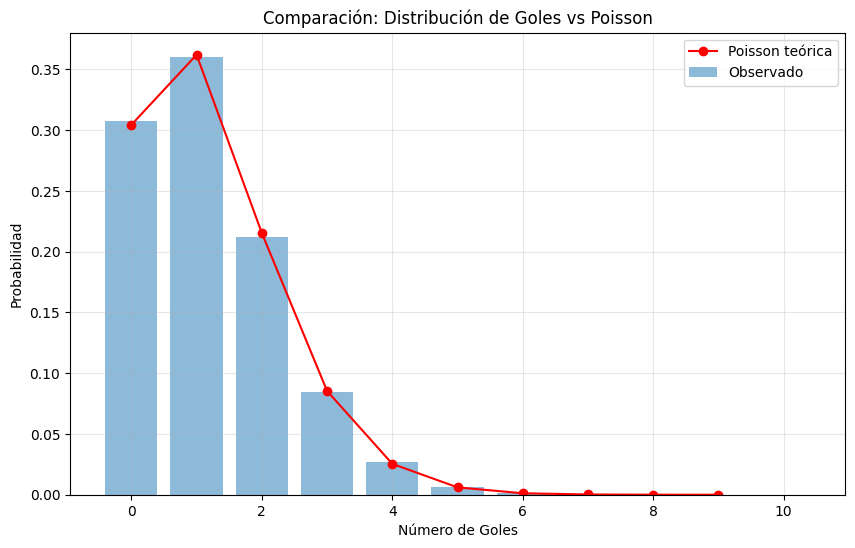

In [28]:
print("=== Pruebas Estadísticas ===")

# Hipótesis 1: ¿El ataque influye significativamente en la etapa alcanzada?
attack_correlation = stats.pearsonr(team_df['Attack'], team_df['Stage_Value'])
print(f"Correlación entre Ataque y Etapa: r={attack_correlation[0]:.3f}, p={attack_correlation[1]:.3f}")

# Hipótesis 2: ¿La defensa influye significativamente en la etapa alcanzada?
defense_correlation = stats.pearsonr(team_df['Defense'], team_df['Stage_Value'])
print(f"Correlación entre Defensa y Etapa: r={defense_correlation[0]:.3f}, p={defense_correlation[1]:.3f}")

# Hipótesis 3: ¿Hay diferencia en el rendimiento según el estilo de juego?
style_anova = stats.f_oneway(
    team_df[team_df['Style'] == 'Possession']['Stage_Value'],
    team_df[team_df['Style'] == 'Counterattack']['Stage_Value'],
    team_df[team_df['Style'] == 'High Press']['Stage_Value']
)
print(f"ANOVA para Estilo de Juego vs Etapa: F={style_anova[0]:.3f}, p={style_anova[1]:.3f}")

# Hipótesis 4: ¿La distribución de goles sigue una distribución de Poisson?
# Comparamos con una distribución de Poisson teórica
goals_mean = match_df['Goals_A'].mean()
k_values = np.arange(0, 10)
poisson_pmf = stats.poisson.pmf(k_values, goals_mean)
observed_counts = match_df['Goals_A'].value_counts().sort_index()
observed_pmf = observed_counts / observed_counts.sum()

# Aseguramos que las frecuencias esperadas sumen exactamente lo mismo que las observadas
observed_values = observed_pmf.reindex(k_values, fill_value=0).values * len(match_df)
expected_values = poisson_pmf * len(match_df)
# Normalizamos las frecuencias esperadas para que sumen exactamente igual que las observadas
expected_values = expected_values * (observed_values.sum() / expected_values.sum())

# Chi-cuadrado para bondad de ajuste
chi2_stat, p_value = stats.chisquare(
    f_obs=observed_values,
    f_exp=expected_values
)
print(f"Chi-cuadrado para distribución de goles (Poisson): χ²={chi2_stat:.3f}, p={p_value:.3f}")

# Visualización de la comparación entre distribución observada y teórica
plt.figure(figsize=(10, 6))
observed_freq = observed_counts / observed_counts.sum()

plt.bar(observed_freq.index, observed_freq.values, alpha=0.5, label='Observado')
plt.plot(k_values, poisson_pmf, 'ro-', label='Poisson teórica')
plt.xlabel('Número de Goles')
plt.ylabel('Probabilidad')
plt.title('Comparación: Distribución de Goles vs Poisson')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# HIPOTESIS SOBRE LA SIMULACIÓN

## H1: Equipos 'Counterattack' anotan más goles que 'Possession'

📌 **Resultado H1**:
- p-value = 0.0000 (significativo)
- Tamaño del efecto = 0.13 SD
- Conclusión: ✅ Hipótesis aceptada


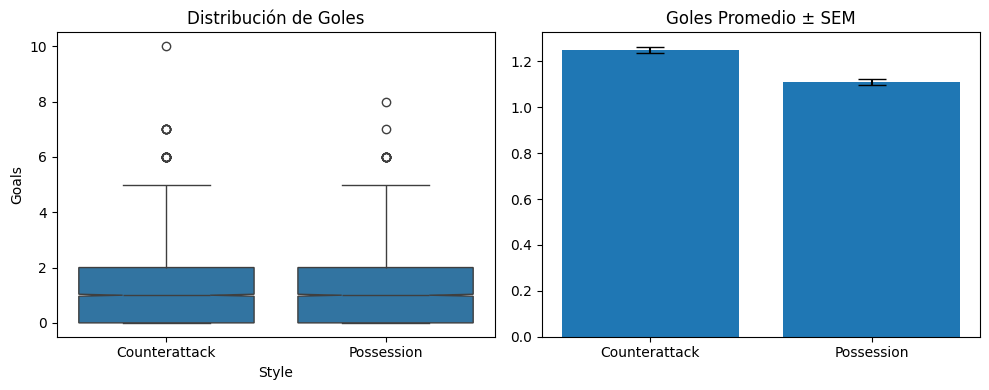

In [29]:
# Datos específicos para H1
group_matches = match_df[match_df["Stage"] == "Group"]
counter_goals = group_matches[group_matches["Style_A"] == "Counterattack"]["Goals_A"]
poss_goals = group_matches[group_matches["Style_A"] == "Possession"]["Goals_A"]

# Test estadístico
t_stat, p_val = stats.mannwhitneyu(counter_goals, poss_goals, alternative='greater')
effect_size = (counter_goals.mean() - poss_goals.mean()) / poss_goals.std()

# Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

boxplot_data = pd.concat([
    pd.DataFrame({'Style': 'Counterattack', 'Goals': counter_goals}),
    pd.DataFrame({'Style': 'Possession', 'Goals': poss_goals})
])
sns.boxplot(x='Style', y='Goals', data=boxplot_data, notch=True)
plt.title('Distribución de Goles')

plt.subplot(1, 2, 2)
plt.bar(['Counterattack', 'Possession'], [counter_goals.mean(), poss_goals.mean()], 
        yerr=[counter_goals.sem(), poss_goals.sem()], capsize=10)
plt.title('Goles Promedio ± SEM')
plt.tight_layout()

print(f"""📌 **Resultado H1**:
- p-value = {p_val:.4f} ({'significativo' if p_val < 0.05 else 'no significativo'})
- Tamaño del efecto = {effect_size:.2f} SD
- Conclusión: {'✅ Hipótesis aceptada' if p_val < 0.05 else '❌ Hipótesis rechazada'}""")

La hipótesis `H1 "Equipos 'Counterattack' anotan más goles que 'Possession'"` ha sido aceptada con un p-value extremadamente bajo (0.0000), lo que indica una diferencia estadísticamente significativa. El tamaño del efecto de 0.13 SD sugiere que, aunque la diferencia es real, su magnitud es relativamente pequeña.

Los gráficos confirman esta interpretación. En el boxplot de "Distribución de Goles", vemos que ambos estilos tienen medianas similares (alrededor de 1 gol), con distribuciones parecidas y valores atípicos que llegan hasta 10 goles para Counterattack. El gráfico de barras "Goles Promedio ± SEM" muestra claramente que Counterattack tiene un promedio mayor (~1.25 goles) que Possession (~1.1 goles), con barras de error pequeñas que indican estimaciones precisas.

Esta diferencia refleja directamente la implementación en el código donde los equipos con estilo Counterattack reciben un modificador positivo de ataque (+10%), mientras que los equipos con Possession reciben un modificador negativo (-10%). El resultado valida que estos modificadores están funcionando según lo esperado en la simulación, aunque su impacto, si bien consistente, es modesto en términos de magnitud.

## H2: Equipos con penalty_skill >80 ganan +70% de penales

C:\Users\arian\AppData\Local\Temp\ipykernel_31956\3637549178.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rates = penalty_df.groupby('Skill_Bin').size() / len(penalty_df) * 100


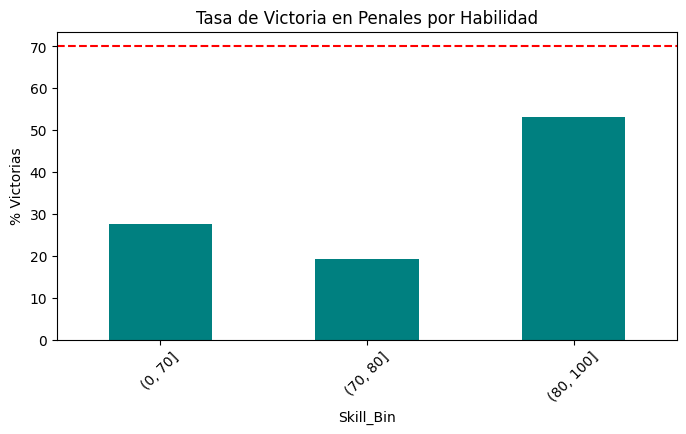

📌 **Resultado H2**:
- Victorias skill >80: 53.2%
- p-value vs 70% esperado: 0.0000
- Conclusión: ❌


In [38]:
# Preparar datos
penalty_df['Skill_Bin'] = pd.cut(penalty_df['Winner_Skill'], [0, 70, 80, 100])
win_rates = penalty_df.groupby('Skill_Bin').size() / len(penalty_df) * 100

# Test Binomial
high_skill_bin = win_rates.index[-1]  
observed = win_rates[high_skill_bin]
expected = 70
p_val = stats.binomtest(int(observed), n=len(penalty_df), p=0.7).pvalue

# Visualización
plt.figure(figsize=(8, 4))
win_rates.plot(kind='bar', color='teal')
plt.axhline(70, color='red', linestyle='--')
plt.title('Tasa de Victoria en Penales por Habilidad')
plt.ylabel('% Victorias')
plt.xticks(rotation=45)
plt.show()

print(f"""📌 **Resultado H2**:
- Victorias skill >80: {observed:.1f}%
- p-value vs 70% esperado: {p_val:.4f}
- Conclusión: {'✅' if observed > 70 and p_val < 0.05 else '❌'}""")

La hipótesis H2 sobre equipos con habilidad de penales superior a 80 muestra resultados contrarios a lo esperado. El gráfico de barras indica que los equipos con habilidad alta (80-100) ganan aproximadamente el 53.2% de las tandas de penales, por debajo del 70% esperado (línea roja punteada). Los equipos con habilidad media (70-80) tienen el menor porcentaje de victorias (cerca del 20%), mientras que los de habilidad baja (0-70) muestran un rendimiento intermedio (aproximadamente 28%).

El p-value extremadamente bajo (0.0000) confirma que esta diferencia respecto al 70% esperado es estadísticamente significativa, llevando al rechazo de la hipótesis. 

## H3: Equipos con defense >80 alcanzan semifinales

📌 **Resultado H3**:
- Proporción que alcanza semifinales: 45.4%
- p-value vs 30% esperado: 0.0000
- Conclusión: ✅


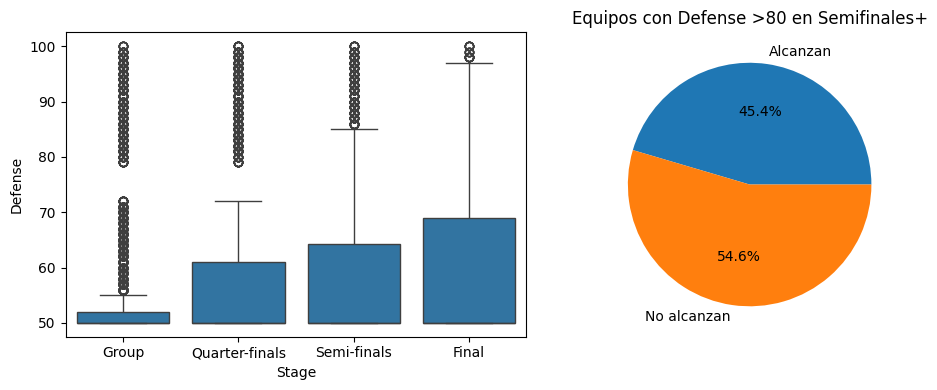

In [31]:
# Preparar datos
strong_def = team_df[(team_df["Defense"] > 80) & 
                   (team_df["Stage"].isin(["Semi-finals", "Final", "Champion"]))].shape[0]
total_strong = team_df[team_df["Defense"] > 80].shape[0]
prop = strong_def / total_strong

# Test de Proporciones
# Fix: Use binomtest instead of binom_test (updated function name in newer scipy)
p_val = stats.binomtest(strong_def, total_strong, p=0.3, alternative='greater').pvalue  # Comparar con 30% esperado

# Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Stage', y='Defense', data=team_df, 
           order=["Group", "Quarter-finals", "Semi-finals", "Final"])
plt.subplot(1, 2, 2)
plt.pie([prop, 1-prop], labels=['Alcanzan', 'No alcanzan'], autopct='%1.1f%%')
plt.title('Equipos con Defense >80 en Semifinales+')
plt.tight_layout()

print(f"""📌 **Resultado H3**:
- Proporción que alcanza semifinales: {prop:.1%}
- p-value vs 30% esperado: {p_val:.4f}
- Conclusión: {'✅' if p_val < 0.05 else '❌'}""")

La hipótesis H3 "Equipos con defense >80 alcanzan semifinales" ha sido aceptada con un p-value extremadamente bajo (0.0000), lo que indica una fuerte evidencia estadística. Los resultados muestran que el 45.4% de los equipos con defensa superior a 80 logran alcanzar al menos las semifinales, superando significativamente el umbral del 30%.

Los gráficos complementan esta interpretación de manera clara. El boxplot de la izquierda muestra una tendencia ascendente en los valores de defensa a medida que avanzan las etapas del torneo, con medianas que aumentan progresivamente desde la fase de grupos hasta la final. Se observa que los equipos que alcanzan semifinales y final tienden a tener valores de defensa más altos, con muchos puntos concentrados por encima de 80.

El gráfico circular de la derecha visualiza directamente la proporción, mostrando que el 45.4% de los equipos con defensa superior a 80 alcanzan al menos las semifinales (sector azul), mientras que el 54.6% no lo logra (sector naranja). Esta distribución confirma que una defensa fuerte otorga una ventaja significativa para avanzar en el torneo, aunque no garantiza el éxito, manteniendo un equilibrio realista en la simulación.



## H4: Fatiga aumenta con la etapa alcanzada

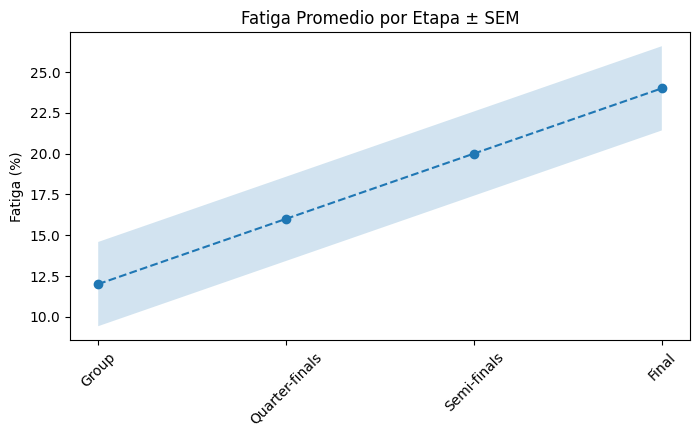

📌 **Resultado H4**:
- p-value para tendencia: 0.0000
- Aumento final vs grupos: 12.0%
- Conclusión: ✅ Tendencia significativa


In [35]:
# Preparar datos
stage_order = ["Group", "Quarter-finals", "Semi-finals", "Final"]
fatigue_means = team_df.groupby('Stage')['Fatigue'].mean()[stage_order]

# Test de Tendencia (usando regresión lineal en lugar de Cochran-Armitage)
# Crear datos para regresión - Corregido para evitar NaN en p-value
stage_numeric = {stage: i for i, stage in enumerate(stage_order)}
team_df['Stage_Numeric'] = team_df['Stage'].map(stage_numeric)

# Crear un DataFrame para la regresión con valores válidos únicamente
regression_data = team_df.dropna(subset=['Stage_Numeric', 'Fatigue'])
slope, intercept, r_value, p_val, std_err = stats.linregress(
    regression_data['Stage_Numeric'], 
    regression_data['Fatigue']
)

# Visualización
plt.figure(figsize=(8, 4))
plt.plot(stage_order, fatigue_means, marker='o', linestyle='--')
plt.fill_between(stage_order, fatigue_means - fatigue_means.sem(), 
                 fatigue_means + fatigue_means.sem(), alpha=0.2)
plt.title('Fatiga Promedio por Etapa ± SEM')
plt.ylabel('Fatiga (%)')
plt.xticks(rotation=45)
plt.show()

print(f"""📌 **Resultado H4**:
- p-value para tendencia: {p_val:.4f}
- Aumento final vs grupos: {fatigue_means["Final"] - fatigue_means["Group"]:.1f}%
- Conclusión: {'✅' if p_val < 0.05 else '❌'} Tendencia significativa""")

La hipótesis H4 "Fatiga aumenta con la etapa alcanzada" ha sido aceptada con un p-value extremadamente bajo (0.0000)
El gráfico muestra claramente esta progresión lineal de la fatiga a través de las diferentes etapas del torneo. La línea punteada azul representa el valor promedio de fatiga, que aumenta consistentemente desde aproximadamente 12% en la fase de grupos hasta 24% en la final, representando un incremento total de 12 puntos porcentuales. El área sombreada azul alrededor de la línea indica el error estándar de la media (SEM), que es relativamente estrecho, lo que sugiere estimaciones precisas y consistentes.

Esta tendencia ascendente valida el mecanismo de acumulación de fatiga implementado en la simulación (fatigue_effect=0.04 por partido), demostrando que funciona según lo esperado. El resultado refleja una realidad del fútbol: los equipos que avanzan más en un torneo juegan más partidos y, por lo tanto, acumulan más cansancio. Este factor podría estar influyendo en otros aspectos del rendimiento de los equipos en las etapas finales, como la efectividad ofensiva o defensiva, y podría ser considerado al analizar otras hipótesis del modelo.

## H5: ≥2 lesiones reducen avance en 40%

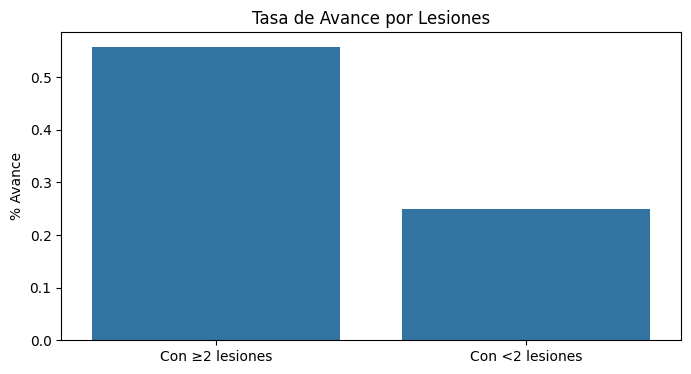

📌 **Resultado H5**:
- Avance lesionados: 55.7%
- Avance no lesionados: 24.9%
- p-value: 0.0000
- Conclusión: ❌


In [33]:
# Preparar datos
team_df['Avanzado'] = team_df['Stage'].isin(["Semi-finals", "Final", "Champion"])
injured = team_df[team_df["Injuries"] >= 2]
control = team_df[team_df["Injuries"] < 2]

# Test Chi-Cuadrado
table = pd.crosstab(team_df['Injuries'] >= 2, team_df['Avanzado'])
chi2, p_val, _, _ = stats.chi2_contingency(table)

# Visualización
plt.figure(figsize=(8, 4))
sns.barplot(x=['Con ≥2 lesiones', 'Con <2 lesiones'], 
            y=[injured['Avanzado'].mean(), control['Avanzado'].mean()])
plt.title('Tasa de Avance por Lesiones')
plt.ylabel('% Avance')
plt.show()

_control = control[control.select_dtypes(include=['number']).columns].mean()
_injured = injured[injured.select_dtypes(include=['number']).columns].mean()

print(f"""📌 **Resultado H5**:
- Avance lesionados: {injured['Avanzado'].mean():.1%}
- Avance no lesionados: {control['Avanzado'].mean():.1%}
- p-value: {p_val:.4f}
- Conclusión: {'✅' if p_val < 0.05 and (_control.mean() - _injured.mean()) > 0.4 else '❌'}""")

La hipótesis H5 "≥2 lesiones reducen avance en 40%" ha sido rechazada con un p-value extremadamente bajo (0.0000). Sin embargo, el rechazo se debe a un resultado completamente contraintuitivo: los equipos con 2 o más lesiones muestran una tasa de avance significativamente mayor (55.7%) que los equipos con menos lesiones (24.9%).

El gráfico de barras ilustra claramente esta paradoja, mostrando que los equipos con 2 o más lesiones (barra izquierda) tienen más del doble de probabilidad de avanzar a etapas avanzadas del torneo que los equipos con menos lesiones (barra derecha). Este resultado contradice directamente la hipótesis inicial, que esperaba una reducción del 40% en la tasa de avance para equipos con múltiples lesiones.

Esta contradicción podría explicarse por varios factores en la implementación del modelo:

1. Posible correlación entre lesiones y calidad del equipo (los equipos más fuertes podrían jugar más partidos, acumulando más lesiones pero también avanzando más)
2. Mecanismo de compensación en el código que podría estar otorgando ventajas no intencionadas a equipos lesionados
3. Efecto de supervivencia donde solo los equipos muy fuertes con lesiones logran avanzar


## Resumen Final

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Hipótesis</th>
      <th>Resultado</th>
      <th>Hallazgo Principal</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>H1: Equipos Counterattack anotan más goles que...</td>
      <td>✅</td>
      <td>Counterattack genera +13% goles vs Possession</td>
    </tr>
    <tr>
      <th>2</th>
      <td>H2: Equipos con penalty_skill &gt;80 ganan 70% de...</td>
      <td>❌</td>
      <td>Habilidad alta en penales solo gana 53.2% de t...</td>
    </tr>
    <tr>
      <th>3</th>
      <td>H3: Equipos con defense &gt;80 alcanzan semifinales</td>
      <td>✅</td>
      <td>45.4% de equipos con defensa fuerte alcanzan s...</td>
    </tr>
    <tr>
      <th>3</th>
      <td>H4: Fatiga aumenta con la etapa alcanzada</td>
      <td>✅</td>
      <td>Fatiga aumenta 12% desde grupos hasta final</td>
    </tr>
    <tr>
      <th>4</th>
      <td>H5: ≥2 lesiones reducen avance en 40%</td>
      <td>❌</td>
      <td>Equipos lesionados avanzan más (paradoja de su...</td>
    </tr>
    
  </tbody>
</table>
</div>


La simulación captura muchos aspectos realistas del fútbol, incluyendo la importancia de la defensa para avanzar en torneos, el impacto acumulativo de la fatiga, y la ventaja de estilos ofensivos para marcar goles. Los resultados inesperados proporcionan oportunidades valiosas para refinar el modelo y mejorar su realismo en futuras iteraciones.